In [2]:
#%load_ext autoreload
#%autoreload 2

In [ ]:
import torch, numpy as np
from safetensors.torch import load_file
from preprocessor import Preprocessor, get_density_at_surface_tensor

$$
\renewcommand{\E}{\mathbb E}
\renewcommand{\V}{\mathbb V}
\renewcommand{\C}{\mathcal C}
$$

# Constraint on Density with Projection operator


In this notebook we show the generation of (T, S) profile with a generative model with a constraint applied on density $g(T, S)$ profiles. 


- $K$ : number of vertical layers
- $x \in \R^{K \times 2}$ : (T, S) profiles
- $g : \R^2 \to \R$ : observation function (density in this case)
- $h : \R^K \to \R$ : constraint function on the profiles


In the following code we do the three tasks : 
1. From $N$ (T, S) profiles we train a diffusion model to sample from the observed distribution. 
2. We show that generated profiles doens't naturally respect the constraint 
3. We change the sampling step during generation to respect given constraint

# 0. Data loading

<bound method FigureBase.suptitle of <Figure size 2000x500 with 3 Axes>>

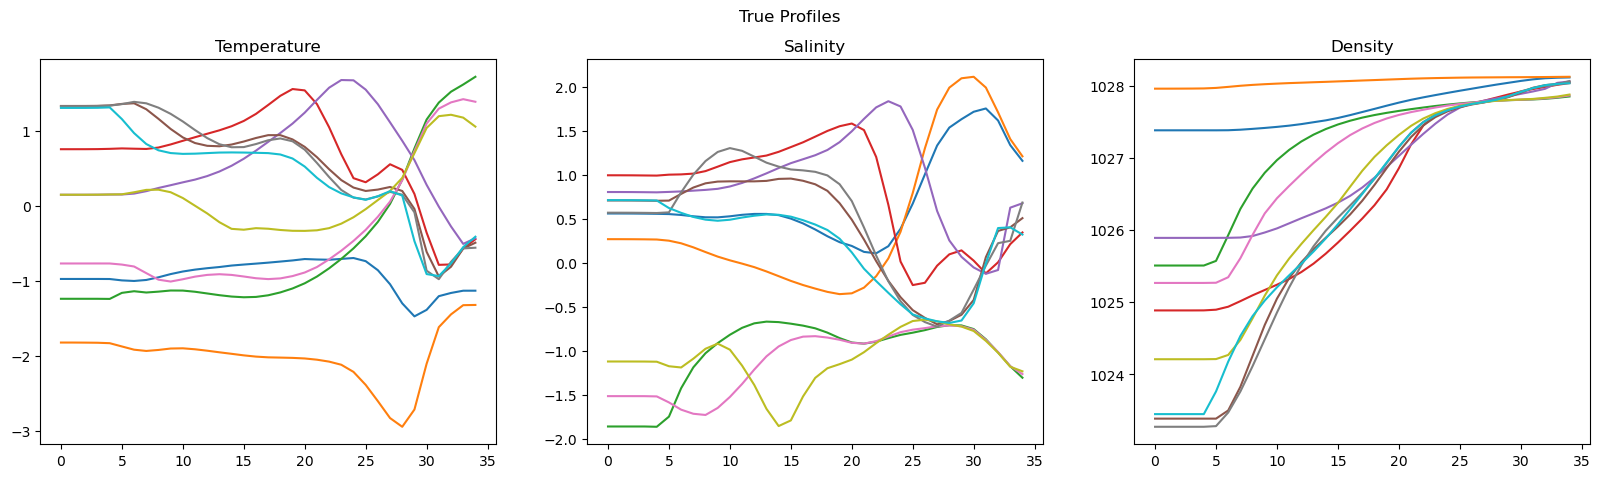

In [6]:
p, levels = 10, 35
stats = load_file('profile_states.safetensor')
toce = torch.tensor(np.load('00000.toce.npy')[:levels, p:-p, p:-p][None])
soce = torch.tensor(np.load('00000.soce.npy')[:levels, p:-p, p:-p][None])

density = get_density_at_surface_tensor(toce, soce)

norm = Preprocessor(toce.shape, stats['mean'], stats['std'], levels)

data_flat_normalised = norm.forward(norm.flatten(toce), norm.flatten(soce))

fig, axs = plt.subplots(1,3,figsize=(20,5))
fig.suptitle('True Profiles')
rindex = torch.randint(0, data_flat_normalised.shape[0], (10,))
axs[0].set_title('Temperature')
axs[0].plot(data_flat_normalised[rindex, :levels].T)
axs[1].set_title('Salinity')
axs[1].plot(data_flat_normalised[rindex, levels:].T)
axs[2].set_title('Density')
axs[2].plot(norm.flatten(density)[rindex, :].T)
fig.suptitle

## 1. Model training

In [21]:
from network import Net
import torch.optim as optim
from tqdm import trange
import torch.distributions as D

In [22]:
targets = data_flat_normalised
N, d = targets.shape

prior = D.MultivariateNormal(torch.zeros(d), torch.eye(d, d))
priors = prior.sample((N,))

In [24]:
u_theta = Net(d)
opt = optim.Adam(u_theta.parameters(), lr=0.001)
epochs = 100
losses = torch.zeros(epochs)

for epoch in trange(epochs) :
    ts = torch.rand((N, 1))
    xs = ts*targets + (1-ts)*priors # sample x from p(x | t, z)
    us = targets - priors
    opt.zero_grad()
    loss = torch.nn.functional.mse_loss(u_theta(xs, ts), us)
    loss.backward()
    opt.step()
    losses[epoch] = loss.item()

100%|██████████| 100/100 [00:05<00:00, 18.43it/s]


## 2. Generate samples

## 3. Constrained generation 

Our objective is sample from the learned distribution constrained by $h$ on the observation $g(x)$

$$
\min_{q} KL(q || p) \quad \text{ s.t } {\E_{q}[h(g(x))]} =0 \text{ and }\E_{q}[h(g(x))^2] \leq \epsilon
$$

In a variational setup (Chamon.) we can operate this sampling formulating a Lagrangian and operating a gradient ascent-descent method. 

**Constraint generation with projection operator :**

Although in our case we don't know how to compute $\nabla_x h$, but we have access to a proximal operator. 

$$
\mathcal P(g) \triangleq_{ \arg \min_{z \in \mathcal C}} ||g - z||^2
$$

where $\mathcal C = \{ z | h(z) = 0 \}$ is the set that respect the constraint. 

We leverage this projection operator and split our problem in two variables : $(x \in \R^{2 \times K}, z \R^{K})$ : 

$$
\min_{q(x, z)} KL(q(x) || p(x)) + \E[X_{\mathcal C}(z)] \quad \text{ s.t } {\E_{q(x, z)}[g(x)-  z]} =0 \text{ and } \E_{q(x,z)}[||g(x) - z||^2] < \epsilon_2
$$

Where $X_{\mathcal C}(x) = \{+ \infty if x \in \mathcal C; 0 if x \notin \mathcal C\}$ is an indicator function. This is similar to what is done in (Blanke) although the objective is slighly different, we are not aiming to get samples respecting exactly the constraint but rather to do sampling respecting the constraint in expectation (with penalization on the variance) in a case where we have a non-differentiable constraint. 

$$
\begin{align}
x_{t+1} =& x + \nabla_x \log p(x) - \nabla_x [\rho ||g(x) - z||^2 + \lambda^T (g(x)-z)] \text{ - Sampling} \\
z_{t+1} &= \arg \min_{z \in \mathcal C} \rho ||g(x) - z||^2 + \lambda^T (g(x)-z) =  \arg \min_{z \in \mathcal C} ||g(x) + (2\rho)^{-1} \lambda - z||\\
\lambda_{t+1} &= \lambda_t + \eta \E[g(x) - z]
\rho_{t+1} =  \big [\rho + \eta \E_{q(x,z)}[||g(x) - z||^2] - \epsilon \big ]_{+}
\end{align}
$$

This algorithm will generally works as long as we have a projection operator for our constraint.  


**Constraints :** 

*1. Average profile* 

Our first constraint is very simple : we want the generated fields have a density profile that is the same as the average density profile $\kappa \in \R^k$. 

This gives a naive projection operator $\mathcal P(g) \triangleq \kappa$

*2. Istononic profile* 

A more sensible constraint is that the density profiles monotically increase with depth $g(x)_{k+1} \leq g(x)_{k} \quad \forall k \in \{0 \times K\}$.

In this setup we define the projection as being the closest profile that monotocally increase $\mathcal P(g) \triangleq_{z \in ??} = ||g -z||^2$ which is the constraint enforced by isotonic regression.